<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1814 | Val: 441 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[ConvNeXt-Tiny] Epoch   1/100 | LR: 1.00e-04 | train loss 0.9782 acc 0.606 | val loss 0.5373 acc 0.760 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 1.00e-04 | train loss 0.5384 acc 0.782 | val loss 0.3825 acc 0.873 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 1.00e-04 | train loss 0.3712 acc 0.854 | val loss 0.3432 acc 0.884 *


[ConvNeXt-Tiny] Epoch   4/100 | LR: 1.00e-04 | train loss 0.2797 acc 0.893 | val loss 0.4392 acc 0.832


...

[ConvNeXt-Tiny] Epoch  12/100 | LR: 1.00e-04 | train loss 0.0717 acc 0.970 | val loss 0.4597 acc 0.848


[ConvNeXt-Tiny] Epoch  13/100 | LR: 1.00e-04 | train loss 0.1356 acc 0.950 | val loss 0.3806 acc 0.896


[ConvNeXt-Tiny] Epoch  14/100 | LR: 1.00e-04 | train loss 0.0817 acc 0.970 | val loss 0.3544 acc 0.900


[ConvNeXt-Tiny] Epoch  15/100 | LR: 1.00e-05 | train loss 0.1009 acc 0.957 | val loss 0.4041 acc 0.889


[ConvNeXt-Tiny] Epoch  16/100 | LR: 1.00e-05 | train loss 0.0548 acc 0.978 | val loss 0.3701 acc 0.900

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 16.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.3096)


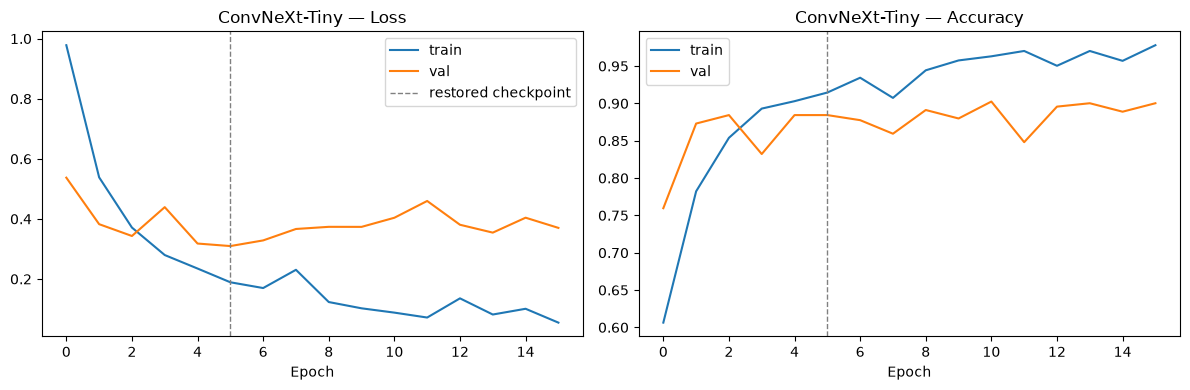

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.718


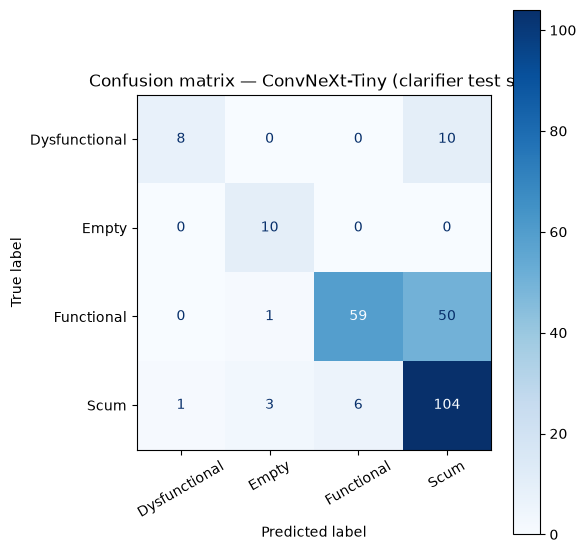

               precision    recall  f1-score   support

Dysfunctional      0.889     0.444     0.593        18
        Empty      0.714     1.000     0.833        10
   Functional      0.908     0.536     0.674       110
         Scum      0.634     0.912     0.748       114

     accuracy                          0.718       252
    macro avg      0.786     0.723     0.712       252
 weighted avg      0.775     0.718     0.708       252



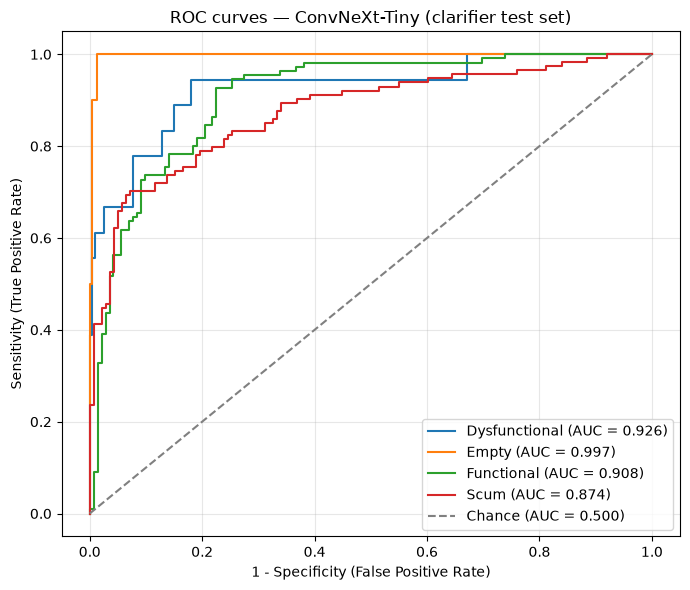

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.926
  Empty          : 0.997
  Functional     : 0.908
  Scum           : 0.874

Mean AUC (over 4/4 classes with test examples): 0.926


(np.float64(0.7182539682539683),
 {'Dysfunctional': 0.9261633428300095,
  'Empty': 0.997107438016529,
  'Functional': 0.9083226632522408,
  'Scum': 0.8739511823035852})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/results_clarifier_convnext_tiny_Fisantekraal.pkl
Saved model weights to ../models/clarifier_convnext_tiny_cnn.pt
